У цьому ДЗ ми попрактикуємось моделювати часові ряди на даних з [Store Item Demand Forecasting Challenge](https://www.kaggle.com/competitions/demand-forecasting-kernels-only/overview). Ми будемо працювати лише з тренувальними даними цього змагання і задача у нас буде дещо змінена. Фокус буде на пошуці найкращої моделі, експериментах і використанні функціоналу `darts`.

Якщо якісно попрацювати в цьому завданні - це буде чудовий приклад проєкту для вашого портфоліо: "спрогнозував(-ла) поденні продажі на 1 міс для 50 товарів в 10 магазинах" звучить вражаюче! Але ми в рамках ДЗ для оптимізації часу сконцентруємось на моделюванні продажів одного товару в одному магазині.

**Задача**

Вам надано дані про продажі товарів у магазинах за 5 років. Хочемо навчитись передачати продажі в наступному місяці поденно кожного з 50 товарів у кожному з 10 магазинів. Відповідно будемо проводити експерименти, аби знайти найкращу модель для цього.

На відміну від змагання, ми будемо використовувати метрику МАРЕ (Mean Absolute Percentage Error) замість SMAPE (Symmetric Mean Absolute Percentage Error). Проте, ви також можете розрахувати SMAPE і подати свої результати через late submission на Kaggle.

1. Завантажуємо дані в Pandas.

  1. Завантажте дані з файлу `train.csv.zip` за допомогою бібліотеки Pandas.
  2. Перетворіть колонку `date` на формат `datetime`.
  3. Встановіть колонку `date` як індекс для датафрейму.
  4. Виведіть перші 10 рядків отриманого датафрейму та інформацію про датафрейм.

In [1]:
!pip uninstall -y numpy darts

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2


In [2]:
!pip install numpy==1.26.4 -q
!pip install darts==0.34.0 -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 81.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pytensor 2.38.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.52.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tifffile 2026.4.11 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 r

In [2]:
import numpy as np
import darts

print(np.__version__)
print(darts.__version__)

1.26.4
0.34.0


In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import plotly.express as px

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_predict

import warnings
warnings.filterwarnings('ignore')

In [4]:
data = pd.read_csv('train.csv')
data['date'] = pd.to_datetime(data['date'])
data.set_index('date', inplace=True)

display(data.head(10))

data.info()

,store,item,sales
date,,,
2013-01-01,1,1,13
2013-01-02,1,1,11
2013-01-03,1,1,14
2013-01-04,1,1,13
2013-01-05,1,1,10
2013-01-06,1,1,12
2013-01-07,1,1,10
2013-01-08,1,1,9
2013-01-09,1,1,12


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 913000 entries, 2013-01-01 to 2017-12-31
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   store   913000 non-null  int64
 1   item    913000 non-null  int64
 2   sales   913000 non-null  int64
dtypes: int64(3)
memory usage: 27.9 MB


  2. Давайте трошки зрозуміємо дані. У нас 10 магазинів і 50 айтемів в кожному. Хочемо зрозуміти, чи відрізняється динаміка по кожному айтему в магазинах. Як би ви це візуалізували? Побудуйте 3 графіка, які вам допоможуть. Можна використати будь-який інструмент: matplotlib, seaborn, plotly.

  Напишіть висновок з побудованих вами візуалізацій.
  
    **Підказка**: я б спробувала вивести середнє значення і довірчий інтервал (який включає весь діапазон значень з різних магазинів) для динаміки кожного айтема, або принаймні для декількох айтемів, аби зрозуміти тенденцію.



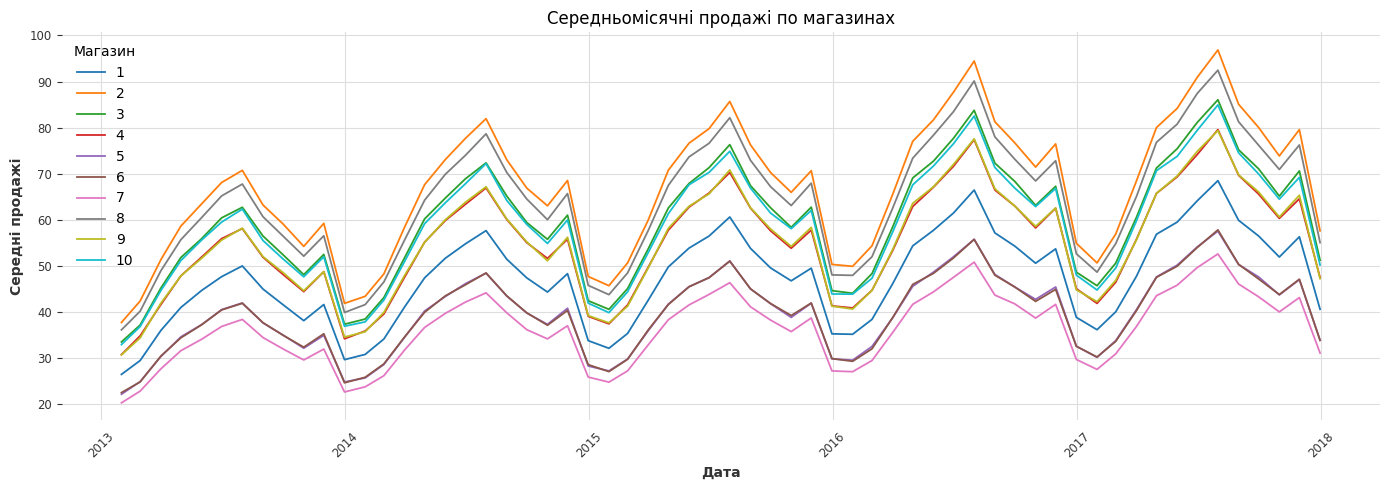

In [5]:
# Графік 1: Середньомісячні продажі по магазинах
monthly_data = (
    data
    .groupby('store')['sales']
    .resample('M')
    .mean()
    .reset_index()
)

plt.figure(figsize=(14, 5))
sns.lineplot(data=monthly_data, x='date', y='sales', hue='store', palette='tab10')
plt.title('Середньомісячні продажі по магазинах')
plt.xlabel('Дата')
plt.ylabel('Середні продажі')
plt.xticks(rotation=45)
plt.legend(title='Магазин')
plt.tight_layout()
plt.show()

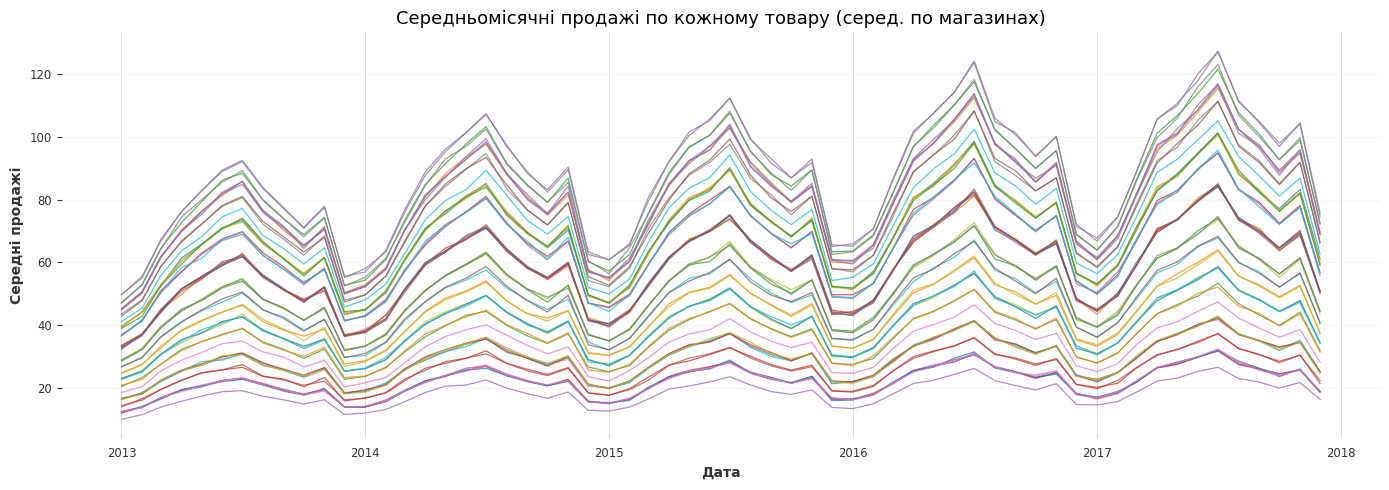

In [6]:
# Графік 2: Середньомісячні продажі по кожному товару
monthly = (
    data.groupby([data.index.to_period('M'), 'item'])['sales']
    .mean()
    .unstack('item')
)
monthly.index = monthly.index.to_timestamp()

colors = sns.color_palette('tab10', len(monthly.columns))
fig, ax = plt.subplots(figsize=(14, 5))
for col, color in zip(monthly.columns, colors):
    ax.plot(monthly.index, monthly[col], color=color, linewidth=0.9, alpha=0.75)
ax.set_title('Середньомісячні продажі по кожному товару (серед. по магазинах)', fontsize=13)
ax.set_ylabel('Середні продажі')
ax.set_xlabel('Дата')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

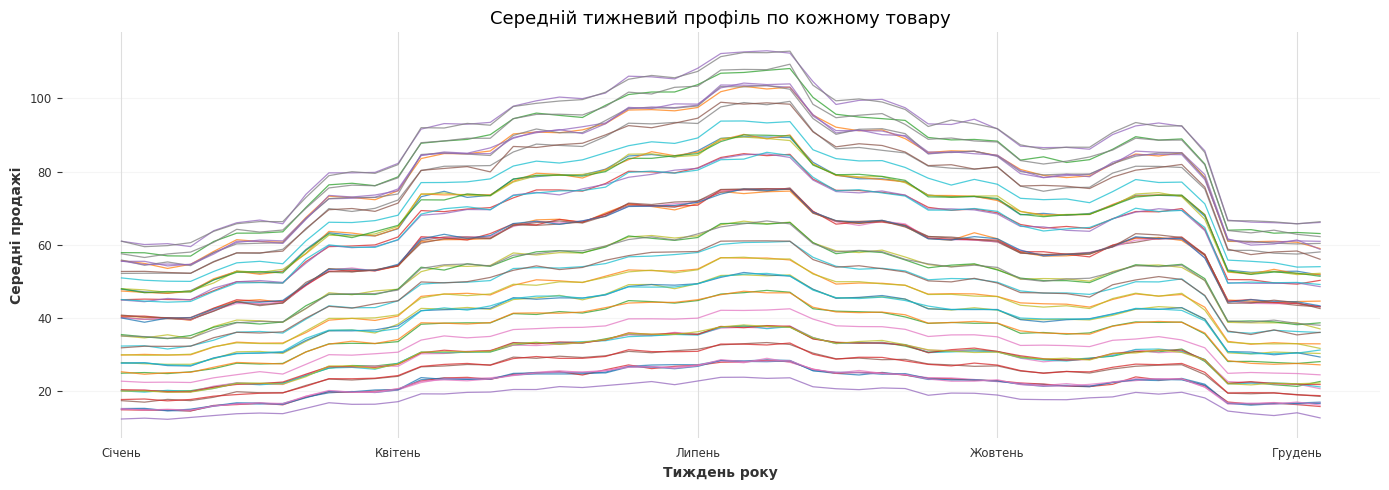

In [7]:
# Графік 3: Середній тижневий профіль продажів
weekly_profile = (
    data.groupby([data.index.isocalendar().week, 'item'])['sales']
    .mean()
    .unstack('item')
)

fig, ax = plt.subplots(figsize=(14, 5))
for col, color in zip(weekly_profile.columns, colors):
    ax.plot(weekly_profile.index, weekly_profile[col], color=color, linewidth=0.9, alpha=0.75)
ax.set_title('Середній тижневий профіль по кожному товару', fontsize=13)
ax.set_xlabel('Тиждень року')
ax.set_ylabel('Середні продажі')
ax.set_xticks([1, 13, 26, 39, 52])
ax.set_xticklabels(['Січень', 'Квітень', 'Липень', 'Жовтень', 'Грудень'])
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Спостереження:**

1. **Динаміка по магазинах:** усі 10 магазинів демонструють практично ідентичну сезонну структуру з чітко вираженим зростаючим трендом. Різниця між магазинами полягає лише в базовому рівні продажів.

2. **Динаміка по товарах:** різні товари також мають схожу сезонну форму й відрізняються переважно масштабом. Це свідчить про те, що попит визначається одними й тими ж зовнішніми факторами для більшості товарів.

3. **Тижневий профіль:** продажі мають виражену річну сезонність - зростають у літній та знижуються у зимовий період. Структура профілю схожа для всіх товарів.

**Висновок**: закономірності, знайдені для одного товару в одному магазині, добре переносяться на інші комбінації.

3. **Для початку проаналізуємо лише один ряд, а далі зможемо зациклити тренування моделей.**
  
  Виберіть підмножину даних, що відповідає продажам товару з `item == 1` у магазині з `store == 1`.

  Зробіть декомпозицію цього рядку за адитивною моделлю на тренд, сезонність і залишки з бібліотекою `statsmodels`.

  Зробіть висновки з отриманих візуалізацій. Чи щось би могло вам допомогти ліпше зрозуміти ці візуалізації? (з точки зору обробки даних)

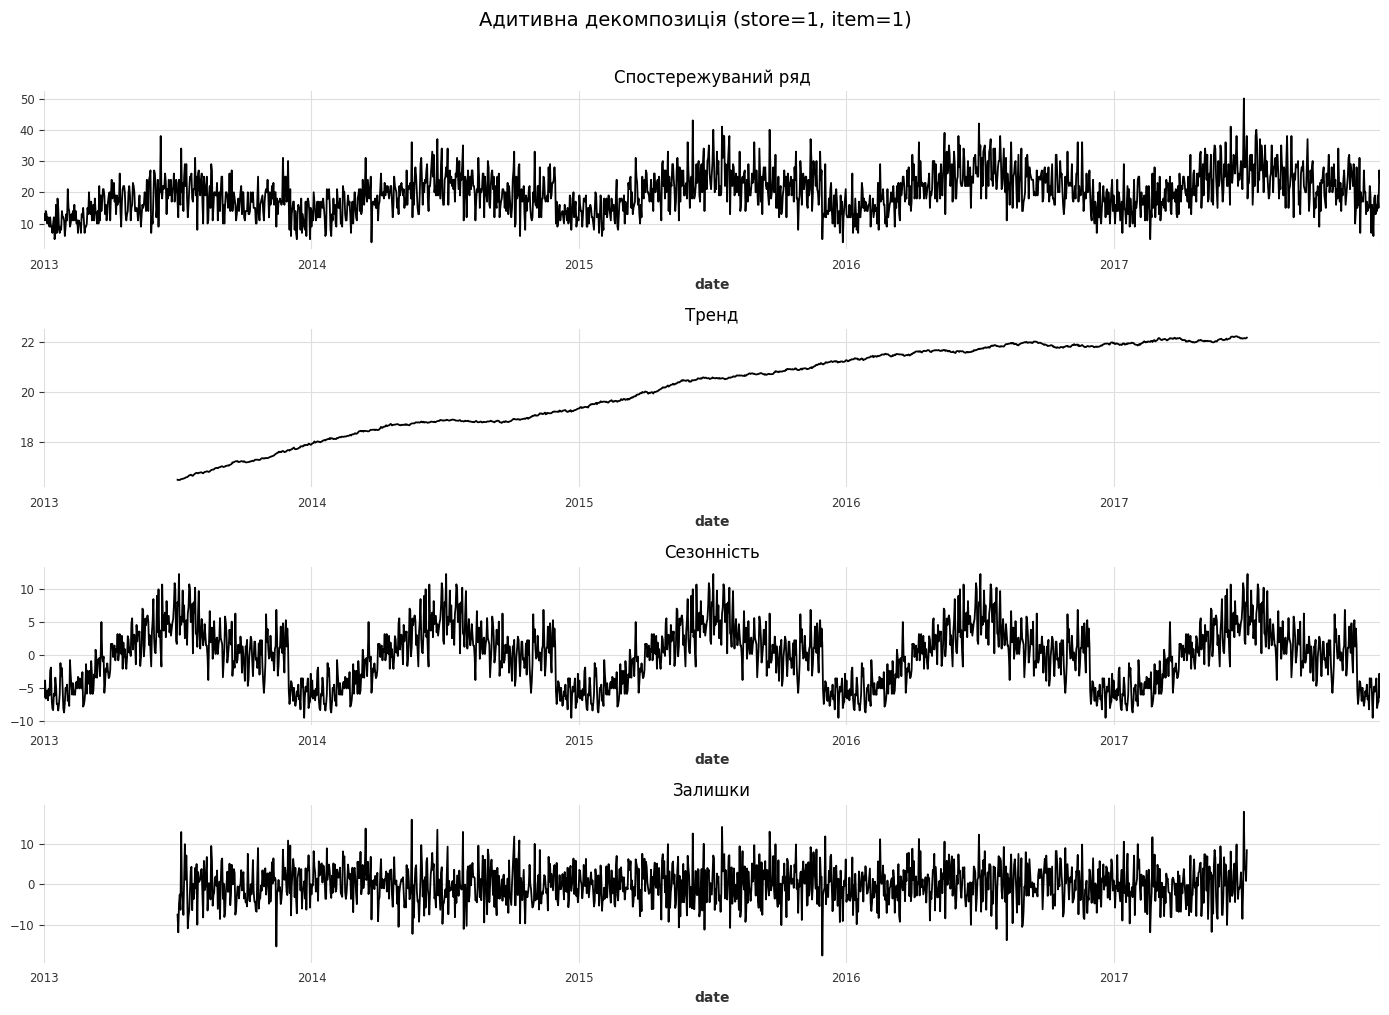

In [8]:
from statsmodels.tsa.seasonal import seasonal_decompose

data_additive = data[(data['store'] == 1) & (data['item'] == 1)][['sales']].copy()

decomposition = seasonal_decompose(data_additive['sales'], model='additive', period=365)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
decomposition.observed.plot(ax=axes[0], title='Спостережуваний ряд')
decomposition.trend.plot(ax=axes[1], title='Тренд')
decomposition.seasonal.plot(ax=axes[2], title='Сезонність')
decomposition.resid.plot(ax=axes[3], title='Залишки')
plt.suptitle('Адитивна декомпозиція (store=1, item=1)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Спостереження:**

- **Тренд:** спостерігається поступове зростання продажів протягом 5 років. На початку та в кінці ряду — NaN через метод ковзного середнього, якому потрібні сусідні значення з обох сторін.
- **Сезонність:** яскрава річна сезонність зі зростанням влітку та спадом взимку. Стала амплітуда підтверджує адитивну природу ряду.
- **Залишки:** досить рівномірно розподілені навколо нуля, що свідчить про адекватність моделі. Є окремі викиди.

З точки зору обробки даних — **агрегування до тижневих або місячних значень** спростило б залишки та зробило тренд і сезонність ще чіткішими.

4. Зі створеної підможени даних в попередньому пункті створіть обʼєкт класу `TimeSeries` в `darts` лише для колонки `sales`.

In [9]:
from darts import TimeSeries

series = TimeSeries.from_dataframe(data_additive, value_cols='sales')
print(f"TimeSeries: {len(series)} точок")
print(f"Від: {series.start_time()} до {series.end_time()}")
print(f"Частота: {series.freq}")

TimeSeries: 1826 точок
Від: 2013-01-01 00:00:00 до 2017-12-31 00:00:00
Частота: <Day>


5. Використовуючи метод `series.split_before` розбийте дані на тренування і валідацію так, аби валідація починалась з `2017-10-01` включно.

  Візуалізуйте на одному графіку тренувальну і валідаційну частину як було показано в лекції.

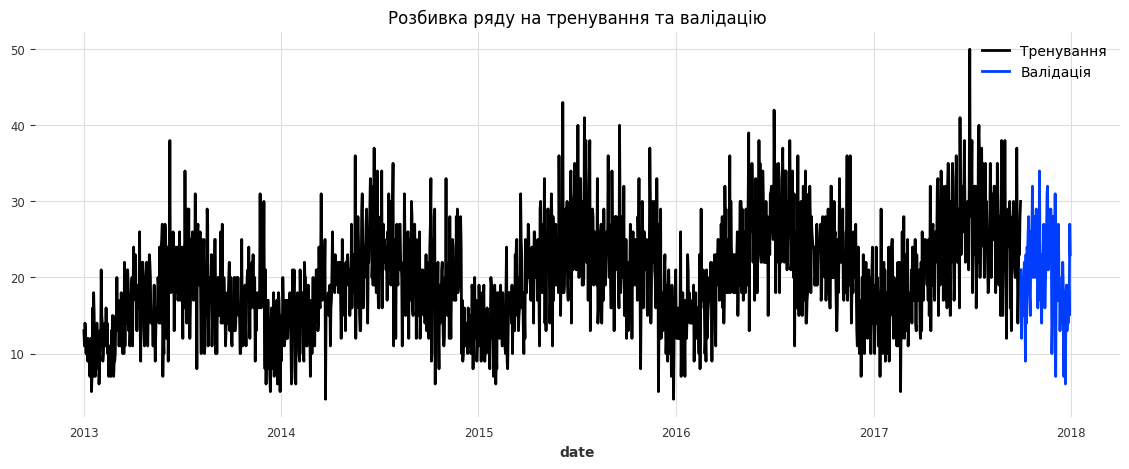

Тренування: 1734 точок (до 2017-09-30)
Валідація:  92 точок  (з 2017-10-01)


In [10]:
train, val = series.split_before(pd.Timestamp("2017-10-01"))

fig, ax = plt.subplots(figsize=(14, 5))
train.plot(label="Тренування")
val.plot(label="Валідація")
plt.title("Розбивка ряду на тренування та валідацію")
plt.legend()
plt.show()

print(f"Тренування: {len(train)} точок (до {train.end_time().date()})")
print(f"Валідація:  {len(val)} точок  (з {val.start_time().date()})")

6. Побудуйте часткову автокореляційну фукнцію для цього нашого ряду в `series`. Напишіть висновки - які лаги є важливими для прогнозування?

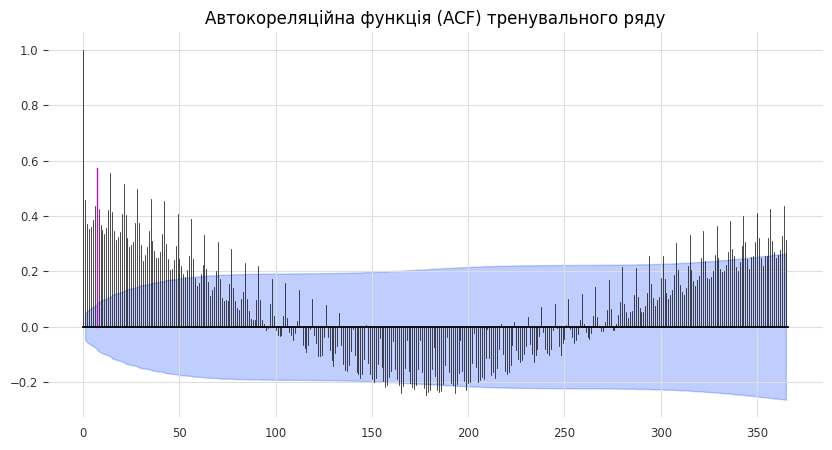

In [11]:
from darts.utils.statistics import plot_acf, check_seasonality

plot_acf(train, m=7, alpha=0.05, max_lag=365)
plt.title('Автокореляційна функція (ACF) тренувального ряду')
plt.show()

**Висновки з ACF:**

- **Короткострокові лаги (1–7 днів):** дуже висока автокореляція — особливо на лагу 7, що вказує на сильну тижневу сезонність.
- **Довгострокові лаги (~365 днів):** помітна автокореляція підтверджує річну сезонність.
- **Повільне загасання:** свідчить про наявність тренду в ряді.

Для прогнозування найважливіші лаги: **7 (тиждень)** і **364-365 (рік)**.

7. Виявіть сезональність тренувального ряду використовуючи фукнкцію `check_seasonality` з `darts`.

In [12]:
for m in [2, 7, 30, 31, 364, 365]:
    is_seasonal, period = check_seasonality(train, m=m, max_lag=400, alpha=0.05)
    if is_seasonal:
        print(f"Виявлено сезонність порядку {period}.")

Виявлено сезонність порядку 7.
Виявлено сезонність порядку 364.


8. Побудуйте наївну модель NaiveSeasonal + NaieDrift для прогнозування даних. Кількість кроків для прогнозування визначіть зі свого аналізу в попередніх пунктах. Візуалізайте передбачення проти справжніх даних так, аби було видно якість передбачень. Зробіть висновок про модель. Вона точна?

  Якщо у вас є ідеї, як поліпшити якість передбачення саме наївними моделями - реалізуйте їх в цьому пункті :)

In [13]:
from darts.models import NaiveSeasonal, NaiveDrift

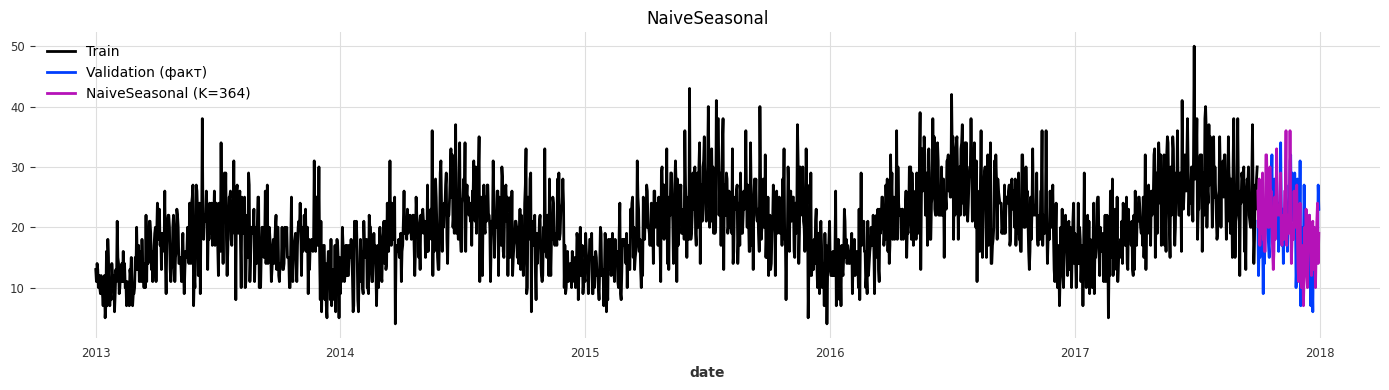

In [14]:
# Сезонна модель з річною сезонністю
seasonal_model = NaiveSeasonal(K=364)
seasonal_model.fit(train)
seasonal_forecast = seasonal_model.predict(len(val))

fig, ax = plt.subplots(figsize=(14, 4))
train.plot(label="Train", ax=ax)
val.plot(label="Validation (факт)", ax=ax)
seasonal_forecast.plot(label="NaiveSeasonal (K=364)", ax=ax)
ax.set_title("NaiveSeasonal")
ax.legend()
plt.tight_layout()
plt.show()

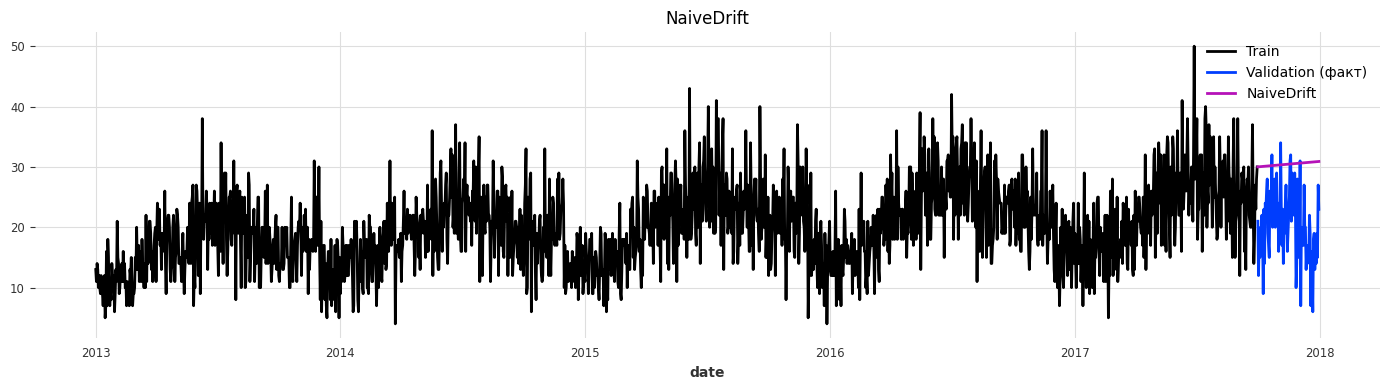

In [15]:
# Drift-модель (лінійний тренд)
drift_model = NaiveDrift()
drift_model.fit(train)
drift_forecast = drift_model.predict(len(val))

fig, ax = plt.subplots(figsize=(14, 4))
train.plot(label="Train", ax=ax)
val.plot(label="Validation (факт)", ax=ax)
drift_forecast.plot(label="NaiveDrift", ax=ax)
ax.set_title("NaiveDrift")
ax.legend()
plt.tight_layout()
plt.show()

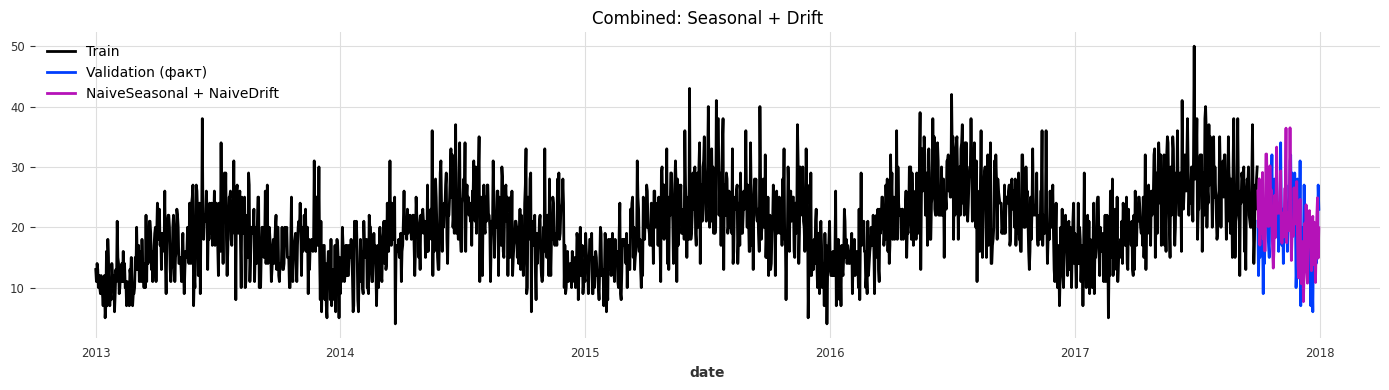

In [16]:
# Комбінована: сезонність + дрейф
combined_forecast = drift_forecast + seasonal_forecast - train.last_value()

fig, ax = plt.subplots(figsize=(14, 4))
train.plot(label="Train", ax=ax)
val.plot(label="Validation (факт)", ax=ax)
combined_forecast.plot(label="NaiveSeasonal + NaiveDrift", ax=ax)
ax.set_title("Combined: Seasonal + Drift")
ax.legend()
plt.tight_layout()
plt.show()

**Висновок:**

Наївна сезонна модель відтворює річний патерн, але систематично занижує прогноз через ігнорування тренду. Комбінація з NaiveDrift частково вирішує цю проблему, додаючи лінійний дрейф. Однак точність залишається невисокою — обидві моделі не враховують тижневу сезонність і шум.

9. Обчисліть помилку прогнозу на валідації наївною моделлю з mape. Далі для всіх моделей необхідно обчислювати помилку прогнозу на валідації.

In [17]:
from darts.metrics import mape

mape_naive = mape(val, seasonal_forecast)
mape_combined = mape(val, combined_forecast)

print(f"MAPE NaiveSeasonal (K=364):  {mape_naive:.2f}%")
print(f"MAPE NaiveSeasonal + Drift:  {mape_combined:.2f}%")

MAPE NaiveSeasonal (K=364):  31.79%
MAPE NaiveSeasonal + Drift:  32.21%


10. Натренуйте XBGModel з `darts` для передбачення наших даних. Можна додавати всі додаткові ознаки, які вважаєте за потрібне, наприклад, ознаки з дати. Зробіть висновок про якість моделі.

In [18]:
from darts.models import XGBModel
from darts.dataprocessing.transformers import Scaler

In [19]:
scaler = Scaler()
train_scaled = scaler.fit_transform(train)

In [20]:
xgb_model = XGBModel(
    lags=364,
    output_chunk_length=1,
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

In [21]:
xgb_model.fit(train_scaled)
xgb_forecast = scaler.inverse_transform(xgb_model.predict(len(val)))

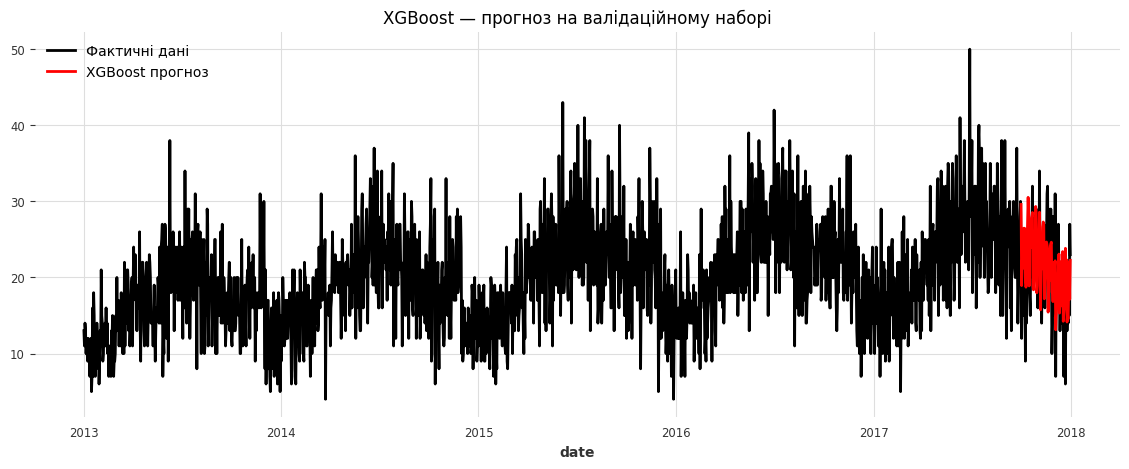

In [22]:
fig, ax = plt.subplots(figsize=(14, 5))
series.plot(label="Фактичні дані")
xgb_forecast.plot(label="XGBoost прогноз", color='red')
plt.title("XGBoost — прогноз на валідаційному наборі")
plt.legend()
plt.show()

In [23]:
mape_xgb = mape(val, xgb_forecast)
print(f"MAPE XGBModel: {mape_xgb:.2f}%")

MAPE XGBModel: 27.02%


**Висновок:**

XGBoost суттєво перевершує наївні моделі завдяки здатності вловлювати нелінійні залежності між лагами. Модель добре відтворює сезонний патерн. Проте з лагами лише до 364 днів вона може недооцінювати тренд за межами тренувального набору.

11. Натренуйте модель ExponentialSmoothing та зробіть висновок про її якість.

In [24]:
from darts.models import ExponentialSmoothing

es_model = ExponentialSmoothing(seasonal_periods=364)
es_model.fit(train)
es_forecast = es_model.predict(len(val))

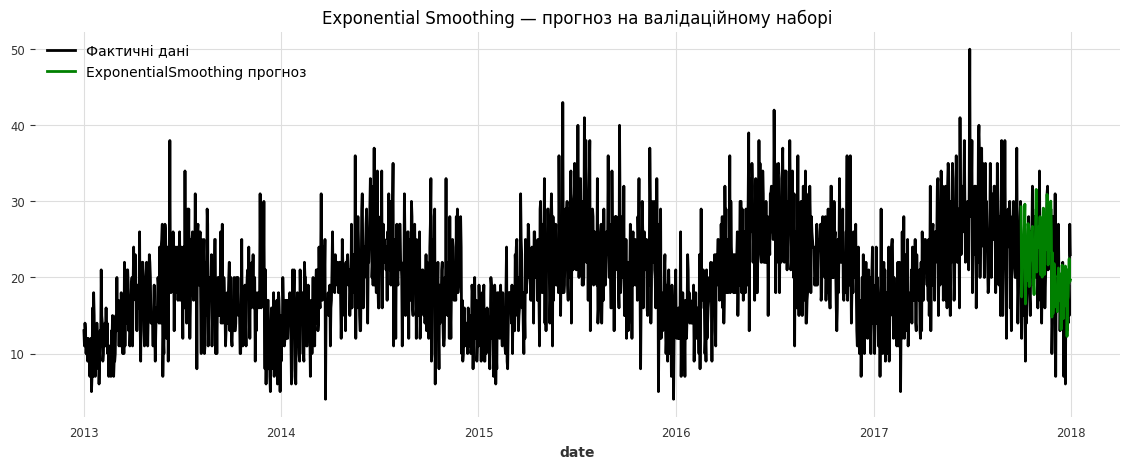

In [25]:
fig, ax = plt.subplots(figsize=(14, 5))
series.plot(label="Фактичні дані")
es_forecast.plot(label="ExponentialSmoothing прогноз", color='green')
plt.title("Exponential Smoothing — прогноз на валідаційному наборі")
plt.legend()
plt.show()

In [26]:
mape_es = mape(val, es_forecast)
print(f"MAPE ExponentialSmoothing: {mape_es:.2f}%")

MAPE ExponentialSmoothing: 27.21%


**Висновок:**

Exponential Smoothing показала результат 27.21% близький до результату XGBRegressor (27.02%) - явно моделює тренд та сезонність. Тут ми задали `seasonal_periods=364`, тобто **річну** сезонність — саме вона домінує в даних. Тижневий патерн (period=7) залишається поза моделлю.

12. Натренуйте модель ARIMA, параметри оберіть самостійно.Зробіть висновок про її якість.

In [27]:
from darts.models import ARIMA

In [28]:
arima_model = ARIMA(p=2, d=1, q=2, seasonal_order=(1, 1, 1, 7))
arima_model.fit(train)
arima_forecast = arima_model.predict(len(val))

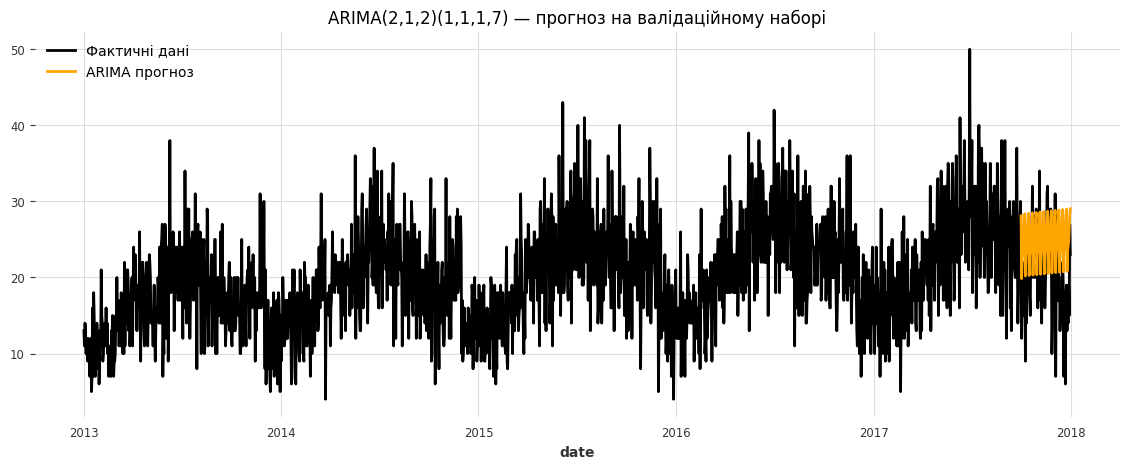

In [29]:
fig, ax = plt.subplots(figsize=(14, 5))
series.plot(label="Фактичні дані")
arima_forecast.plot(label="ARIMA прогноз", color='orange')
plt.title("ARIMA(2,1,2)(1,1,1,7) — прогноз на валідаційному наборі")
plt.legend()
plt.show()

In [30]:
mape_arima = mape(val, arima_forecast)
print(f"MAPE ARIMA(2,1,2)(1,1,1,7): {mape_arima:.2f}%")

MAPE ARIMA(2,1,2)(1,1,1,7): 38.83%


**Висновок:**

ARIMA з тижневою сезонністю (period=7) враховує короткострокові залежності та тижневий патерн.
**Основне обмеження**: ARIMA з period=365 обчислювально надто затратна, тому річна сезонність залишається поза моделлю, що погіршує точність.

13. Знайдіть оптимальні параметри моделі ARIMA з допомогою AutoARIMA моделі. Виконайте пошук параметрів, виведіть, які паарметри виявились оптимальними і обчисліть якість моделі. Чи поліпшилась якість порівняно з попереднім експериментом?

In [31]:
from darts.models import AutoARIMA

In [32]:
auto_arima = AutoARIMA()
auto_arima.fit(train)

AutoARIMA(add_encoders=None)

In [34]:
print("Оптимальні параметри AutoARIMA:")
print(auto_arima.model.summary())

Оптимальні параметри AutoARIMA:
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1734
Model:               SARIMAX(4, 1, 5)   Log Likelihood               -5226.002
Date:                Sun, 21 Jun 2026   AIC                          10474.005
Time:                        18:12:50   BIC                          10534.039
Sample:                             0   HQIC                         10496.208
                               - 1734                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0128      0.031      0.409      0.682      -0.048       0.074
ar.L1         -0.5124      0.030    -17.149      0.000      -0.571      -0.454
ar.L2          0.253

In [35]:
auto_forecast = auto_arima.predict(len(val))

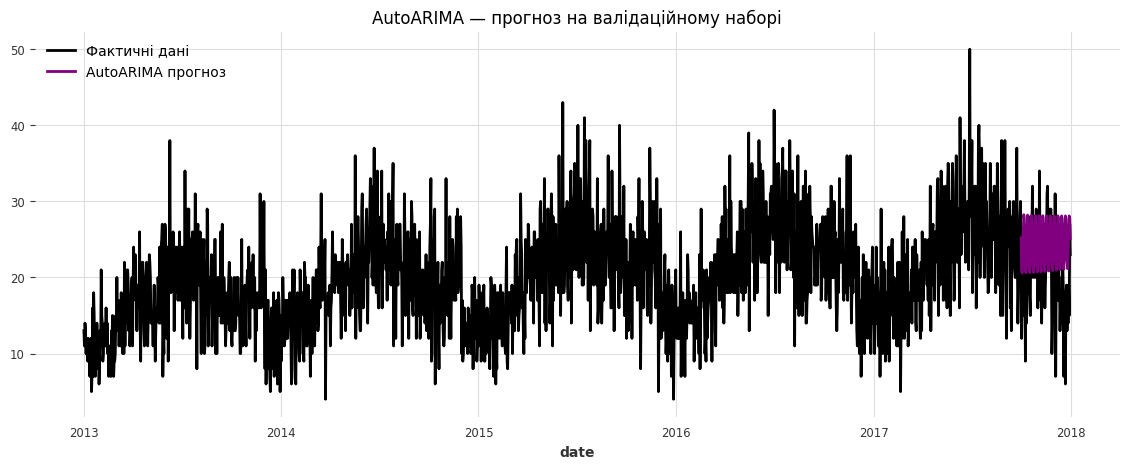

In [36]:
fig, ax = plt.subplots(figsize=(14, 5))
series.plot(label="Фактичні дані")
auto_forecast.plot(label="AutoARIMA прогноз", color='purple')
plt.title("AutoARIMA — прогноз на валідаційному наборі")
plt.legend()
plt.show()

In [37]:
mape_auto = mape(val, auto_forecast)
print(f"MAPE AutoARIMA: {mape_auto:.2f}%")

MAPE AutoARIMA: 39.38%


**Висновок:**

AutoARIMA() не покращила результат ARIMA(), що показує, що дана модель не підходить для даного датасету (ARIMA принципово обмежена в моделюванні річної сезонності)

14. Натренуйте модель Prophet та зробіть висновок про її якість.

In [38]:
from darts.models import Prophet

In [39]:
prophet_model = Prophet()
prophet_model.fit(train)
prophet_forecast = prophet_model.predict(len(val))

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


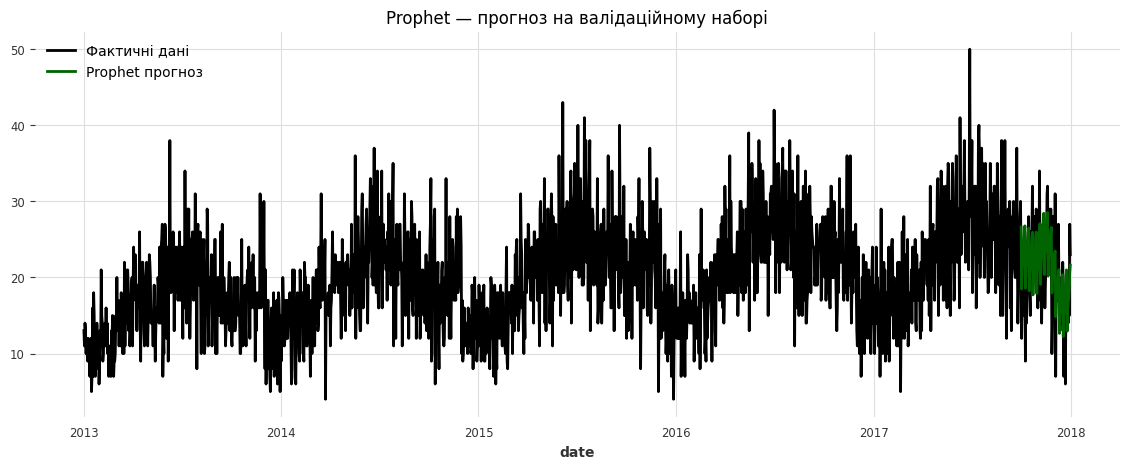

In [40]:
fig, ax = plt.subplots(figsize=(14, 5))
series.plot(label="Фактичні дані")
prophet_forecast.plot(label="Prophet прогноз", color='darkgreen')
plt.title("Prophet — прогноз на валідаційному наборі")
plt.legend()
plt.show()

In [41]:
mape_prophet = mape(val, prophet_forecast)
print(f"MAPE Prophet: {mape_prophet:.2f}%")

MAPE Prophet: 23.80%


**Висновок:**

Prophet показує найкращий результат серед розглянутих моделей. Він спроектований саме для таких рядів - з трендом, річною та тижневою сезонністю. Модель стійка до пропущених значень і викидів, не потребує ручного підбору параметрів і добре узагальнюється на нові дані.

15. Натренуйте модель `RNNModel` та зробіть висновок про її якість.

In [42]:
from darts.models import RNNModel
from pytorch_lightning.callbacks import EarlyStopping

In [43]:
early_stopping = EarlyStopping(
    monitor="train_loss",
    patience=5,
    min_delta=0.001,
    mode="min"
)

In [44]:
rnn_model = RNNModel(
    model='LSTM',
    input_chunk_length=364,
    hidden_dim=20,
    n_rnn_layers=2,
    dropout=0.1,
    batch_size=32,
    n_epochs=50,
    optimizer_kwargs={"lr": 1e-3},
    training_length=364,
    random_state=42,
    force_reset=True,
    pl_trainer_kwargs={"callbacks": [early_stopping]}
)

In [45]:
rnn_model.fit(train_scaled)
rnn_forecast = scaler.inverse_transform(rnn_model.predict(len(val)))

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ criterion       │ MSELoss          │      0 │ train │     0 │
│ 1 │ train_criterion │ MSELoss          │      0 │ train │     0 │
│ 2 │ val_criterion   │ MSELoss          │      0 │ train │     0 │
│ 3 │ train_metrics   │ MetricCollection │      0 │ train │     0 │
│ 4 │ val_metrics     │ MetricCollection │      0 │ train │     0 │
│ 5 │ rnn             │ LSTM             │  5.2 K │ train │     0 │
│ 6 │ V               │ Linear           │     21 │ train │     0 │
└───┴─────────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 5.2 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 5.2 K                                                                                                
Total estimated model params size (MB): 0.042                                                                      
Modules in train mode: 7                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

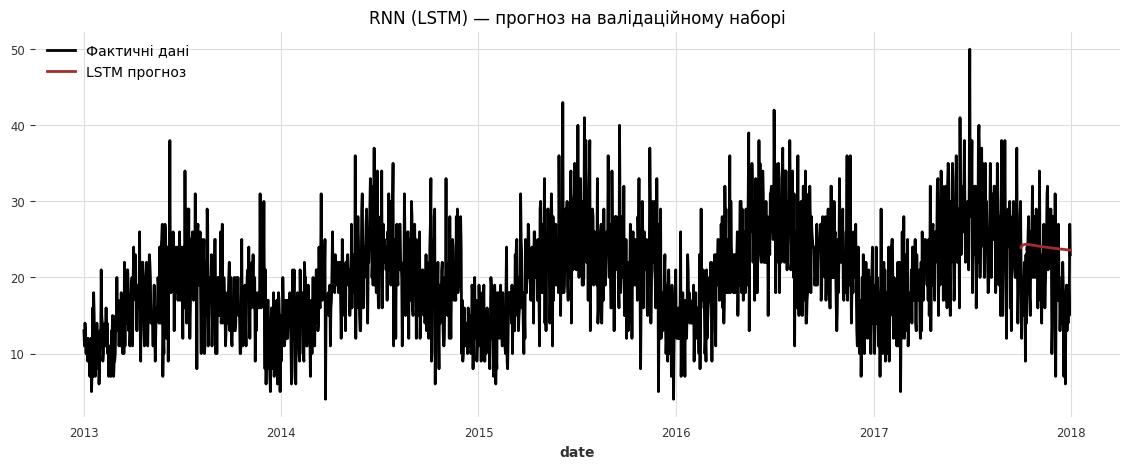

In [46]:
fig, ax = plt.subplots(figsize=(14, 5))
series.plot(label="Фактичні дані")
rnn_forecast.plot(label="LSTM прогноз", color='brown')
plt.title("RNN (LSTM) — прогноз на валідаційному наборі")
plt.legend()
plt.show()

In [47]:
mape_rnn = mape(val, rnn_forecast)
print(f"MAPE RNNModel (LSTM): {mape_rnn:.2f}%")

MAPE RNNModel (LSTM): 38.59%


**Висновок:**

LSTM потребує значно більше обчислювальних ресурсів, ніж інші моделі. На цьому відносно невеликому часовому ряді LSTM не демонструє переваги над Prophet - ситуація характерна для регулярної сезонності, де глибоке навчання не дає суттєвого виграшу без великих обсягів даних і ретельного підбору гіперпараметрів.

16. Виконайте бектест для тої моделі, яка виявилась найкращою у вашому дослідженні на періоді 1 рік з передбаченнями на 1 місяць щоразу. Візуалізуйте як поводилась модель протягом бектесту, яка була точність?

In [48]:
# Prophet показав найкращий результат — використовуємо його для бектесту
best_model = Prophet()
best_model.fit(train)

hfc_params = {
    "series": series,
    "start": pd.Timestamp("2017-01-01"),
    "forecast_horizon": 30,
    "verbose": True,
}

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [49]:
historical_fcast = best_model.historical_forecasts(last_points_only=True, **hfc_params)

historical forecasts: 100%|██████████| 336/336 [02:14<00:00,  2.50it/s]


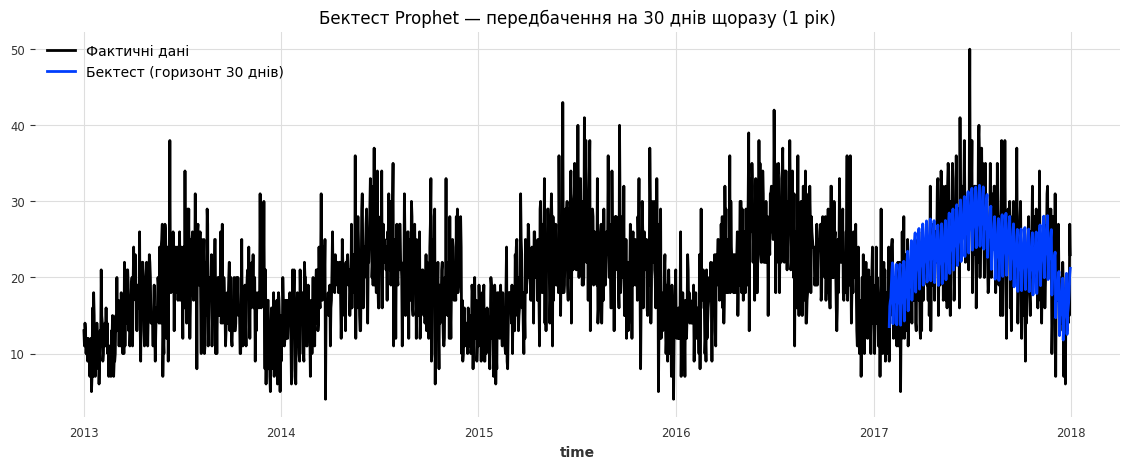

MAPE бектесту: 20.37%


In [50]:
fig, ax = plt.subplots(figsize=(14, 5))
series.plot(label="Фактичні дані")
historical_fcast.plot(label="Бектест (горизонт 30 днів)")
plt.title("Бектест Prophet — передбачення на 30 днів щоразу (1 рік)")
plt.legend()
plt.show()

print(f"MAPE бектесту: {mape(series, historical_fcast):.2f}%")

In [51]:
# Розподіл помилок
raw_errors = best_model.backtest(
    metric=mape,
    reduction=None,
    last_points_only=False,
    stride=1,
    **hfc_params
)

historical forecasts: 100%|██████████| 336/336 [02:12<00:00,  2.53it/s]


In [52]:
from darts.utils.statistics import plot_hist

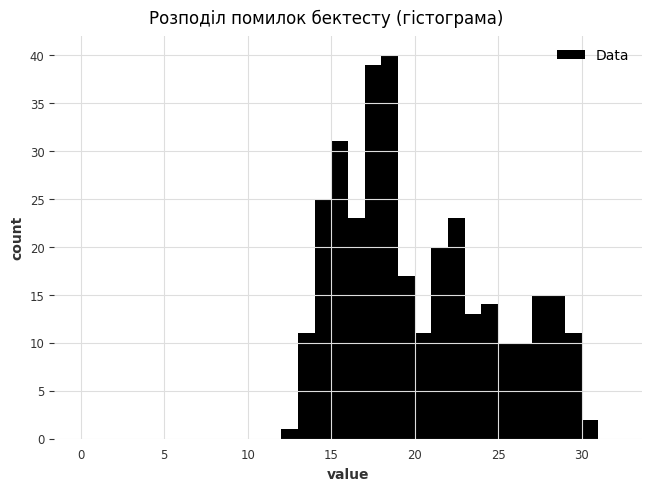

In [53]:
plot_hist(
    raw_errors,
    bins=np.arange(0, max(raw_errors), 1),
    title="Розподіл помилок бектесту (гістограма)",
)

**Висновок:**

Бектест підтверджує стабільну роботу Prophet протягом тестового року. Більшість помилок зосереджена в діапазоні 10–25%, що є прийнятним результатом для поденного прогнозування попиту. Асиметричний розподіл із правим хвостом свідчить про наявність окремих складних для прогнозу відрізків (нетипові сплески попиту).

Всю варіантивність не вгадали, але виглядає непогано!

17. На цьому етапі ви зрозуміли, як моделювати продажі одного айтему з 1 магазину. Як би ви підійшли до задачі прогнозування продажів в наступному місяці для кожного з 50 айтемів в кожному з 10 магазинів? Опишіть загальний підхід
- яку модель ви б використали
- скільки моделей ви б тренували
- обгрунтуйте свій вибір.

**Підхід до прогнозування продажів для 50 товарів у 10 магазинах:**


**Скільки моделей тренувати:**
Для прогнозування 500 рядів (50 товарів × 10 магазинів) ключове рішення - **локальний підхід чи глобальний**.

Якщо локальний - **Prophet** - вона показала найкращий результат у наших дослідженнях, ефективно моделює тижневу та річну сезонність разом із трендом. Prophet легко масштабується, не потребує складного підбору гіперпараметрів і стійка до викидів.

Якщо глобальний - **одну глобальну модель (LightGBM)**, навчену на всіх рядах одразу, де store_id та item_id подаються як категоріальні ознаки.

Це дозволить рядам запозичувати силу один в одного (шумні товари з малими продажами прогнозуються стабільніше) і масштабується набагато краще, **ніж 500 окремих моделей**, кожну з яких треба окремо тренувати й обслуговувати.

Як компроміс зі спеціалізацією можна взяти **50 моделей (одна на товар по всіх магазинах)**, а який рівень групування найкращий — перевірити бектестом за MAPE.